In [ ]:
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

from mbloodmoon.types import CoordEquatorial
from mbloodmoon.coords import shift2equatorial

from temp_camera import codedmask

def _get_mask(mask: str) -> str:
    """Retrieve WFM mask pattern path."""

    if Path(base_path := "/mnt/dbb8f47e-da06-47bf-8ef5-038092af70f7/Edos_Magnificent_Manor/PhD_AASS/Coding/IROS_Data/").is_dir():
        mask_path = base_path + "Simulations/" + mask
    elif Path(base_path := "/mnt/d/PhD_AASS/Coding/Images_fits/").is_dir():
        mask_path = base_path + mask
    else:
        raise ValueError("A0, ma ndo sei finit*?")
    
    if not Path(mask_path).is_file():
        raise ValueError(f"WFM mask '{mask}' does not exist.")

    return mask_path


@dataclass(frozen=True)
class MiniSDL:
    """Test SimulationDataLoader instance with camera pointing."""

    CAMZRA: float
    CAMZDEC: float
    CAMXRA: float
    CAMXDEC: float

    @property
    def pointings(self) -> dict[str, CoordEquatorial]:
        """
        Camera axis pointing information in equatorial frame.
        Angles are expressed in degrees.
        """
        return {
            "z": CoordEquatorial(ra=self.CAMZRA, dec=self.CAMZDEC),
            "x": CoordEquatorial(ra=self.CAMXRA, dec=self.CAMXDEC),
        }

Sources: 9


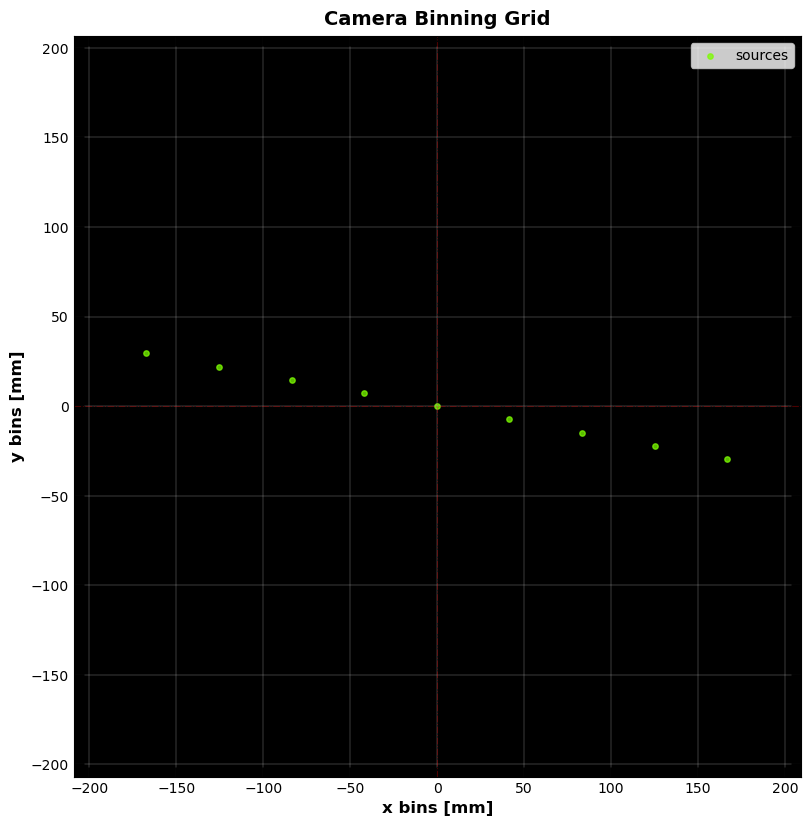

In [ ]:
mask_FITS = "wfm_mask.fits"
mask_path = _get_mask(mask_FITS)

UPX, UPY = 3, 5

wfm = codedmask(mask_path, UPX, UPY)
sdl = MiniSDL(
    CAMZRA=266.4,
    CAMZDEC=-28.94,
    CAMXRA=266.4,
    CAMXDEC=61.06,
)


div = 10
m = -10


skyx, skyy = wfm.bins_sky
step = len(skyx) // div
t = skyx[::step][1:-1]
w = np.tan(np.deg2rad(m)) * t # (t + np.random.normal(0, 1, len(t))) + np.random.normal(0, 5, len(t))
print(f"Sources: {len(w)}")


fig, ax = plt.subplots(1, 1, figsize=(8, 8))
fig.tight_layout()
ax.add_patch(patches.Rectangle((skyx[0], skyy[0]), skyx[-1] - skyx[0], skyy[-1] - skyy[0], linewidth=1, edgecolor='k', facecolor='k'))
plt.plot((skyx[0], skyx[-1]), (0, 0), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
plt.plot((0, 0), (skyy[0], skyy[-1]), color='r', linestyle='dashdot', linewidth=0.75, alpha=0.3)
plt.scatter(t, w, color="LawnGreen", alpha=0.75, s=15, label="sources")
plt.xlim((skyx[0], skyx[-1]))
plt.ylim((skyy[0], skyy[-1]))
ax.set_xlabel("x bins [mm]", fontsize=12, fontweight='bold')
ax.set_ylabel("y bins [mm]", fontsize=12, fontweight='bold')
ax.set_title("Camera Binning Grid", fontsize=14, pad=8, fontweight='bold')
ax.grid(visible=True, color="lightgray", linestyle="-", linewidth=0.2)
ax.tick_params(which='both', direction='in', width=2, length=7 if 'major' else 4)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
ax.legend(loc='best')
plt.show()

In [ ]:
catalogue = []

for shiftx, shifty in zip(t, w):
    ra, dec = shift2equatorial(sdl, wfm, shiftx, shifty)
    flux = 0.005
    catalogue.append((ra, dec, flux))


path = "/home/edoardo/Desktop/"
name = "test_shortcatalogue_obliquedistr.csv"

df = pd.DataFrame(catalogue, columns=["RA", "DEC", "FLUX"])
df.to_csv(path_or_buf=path + name, index=False)

df